# Fraud Detection —>Baseline Model & Validation

A compact, **interview-ready** notebook on the PaySim dataset. It does three things:

1. Builds a simple supervised baseline —>**Logistic Regression** —>to predict fraud.
2. **Evaluates it the way a model-risk reviewer would** —>not just accuracy, but precision/recall, ROC-AUC, PR-AUC, and the decision threshold.
3. Adds an unsupervised **Isolation Forest** cross-check that needs no labels.

### What's improved over a basic version (worth pointing out in the interview)
| Improvement | Why it matters |
|---|---|
| **Stratified** train/test split | Fraud is ~0.1% of rows —>a plain split can leave too few fraud cases in the test set |
| **Pipeline** (scaling + model) | Scaling is fit on *training data only*, inside the pipeline → **no data leakage** |
|**`class_weight="balanced"`**| Tells the model the minority (fraud) class matters, despite being rare |
| **PR-AUC** alongside ROC-AUC | On highly imbalanced data, PR-AUC is the more honest summary |
| **Threshold analysis** | The 0.5 cut-off is a *business choice*; missing fraud usually costs more than a false alarm |
| A **validator's lens** section | States assumptions, limitations, and what to check next —>the model-risk mindset |

> **To run on the real data:** download PaySim from Kaggle (`ealaxi/paysim1`) and put it at `../data/PS_20174392719_1491204439457_log.csv`. If that file isn't present, the next cell generates a small synthetic sample with the **same columns**, so the notebook always runs.

## 1. Import libraries

- **pandas / numpy** —>data handling and numbers
- **scikit-learn** —>the split, the Pipeline, the models, and the metrics
- **matplotlib** —>one precision–recall plot

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score, precision_recall_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the data

PaySim simulates mobile-money transactions. The columns we use:

- `type` —>PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT
- `amount` —>transaction amount
- `oldbalanceOrg`, `newbalanceOrig` —>sender's balance before / after
- `isFraud` —>the label (1 = fraud)

The loader below uses the real Kaggle file if it exists, otherwise it builds a
small synthetic sample with identical columns so the notebook runs anywhere.
The synthetic fraud follows PaySim's documented pattern (fraud appears only in
TRANSFER / CASH_OUT and drains the account), so the model has a real signal to learn.

In [19]:
def make_synthetic_paysim(n=80_000, fraud_rate=0.003, seed=RANDOM_STATE):
    """Tiny stand-in with the same columns as PaySim, for when the real file is absent.

    The fraud signal is deliberately NOISY and OVERLAPPING with legitimate
    activity, so the model is strong but not perfect -- which is what makes the
    precision/recall and threshold discussion meaningful (just like real data)."""
    rng = np.random.default_rng(seed)
    types = rng.choice(["PAYMENT", "CASH_OUT", "CASH_IN", "TRANSFER", "DEBIT"],
                       size=n, p=[0.34, 0.35, 0.22, 0.08, 0.01])
    amount = np.round(rng.lognormal(6.5, 1.1, size=n), 2)
    old_org = np.round(rng.uniform(0, 50_000, size=n), 2)
    new_org = np.where(np.isin(types, ["CASH_IN"]),
                       old_org + amount, np.maximum(old_org - amount, 0)).round(2)
    df = pd.DataFrame({
        "step": rng.integers(1, 720, size=n),
        "type": types, "amount": amount,
        "nameOrig": ["C%d" % i for i in rng.integers(1e8, 1e9, size=n)],
        "oldbalanceOrg": old_org, "newbalanceOrig": new_org,
        "nameDest": ["C%d" % i for i in rng.integers(1e8, 1e9, size=n)],
        "oldbalanceDest": np.round(rng.uniform(0, 50_000, size=n), 2),
        "newbalanceDest": np.round(rng.uniform(0, 50_000, size=n), 2),
        "isFraud": 0, "isFlaggedFraud": 0,
    })

    # Some legitimate large CASH_OUTs also drain the account -> false-positive pressure.
    big = df.index[(df["type"] == "CASH_OUT") &
                   (df["amount"] > np.quantile(df["amount"], 0.985))].to_numpy()
    df.loc[big, "oldbalanceOrg"] = (df.loc[big, "amount"] * rng.uniform(0.9, 1.1, len(big))).round(2)
    df.loc[big, "newbalanceOrig"] = np.maximum(
        df.loc[big, "oldbalanceOrg"] - df.loc[big, "amount"], 0).round(2)

    # Fraud: big TRANSFER/CASH_OUT that USUALLY empties the account -- but noisy,
    # and the amounts overlap the legitimate tail, so it isn't trivially separable.
    eligible = df.index[df["type"].isin(["TRANSFER", "CASH_OUT"])].to_numpy()
    k = int(n * fraud_rate)
    idx = rng.choice(eligible, size=k, replace=False)
    f_amount = np.round(rng.lognormal(9.3, 1.2, size=k), 2)           # overlaps legit tail
    df.loc[idx, "amount"] = f_amount
    df.loc[idx, "oldbalanceOrg"] = (f_amount * rng.uniform(0.5, 1.5, size=k)).round(2)
    drained = rng.random(k) < 0.7                                    # only ~70% fully drain
    df.loc[idx, "newbalanceOrig"] = np.where(
        drained,
        np.maximum(df.loc[idx, "oldbalanceOrg"].to_numpy() - f_amount, 0),
        rng.uniform(0, 20_000, size=k)).round(2)
    df.loc[idx, "isFraud"] = 1
    return df



#========================================OR=================================================#


PAYSIM_PATH = r"C:\Users\highm\Downloads\paysim.csv"
if os.path.exists(PAYSIM_PATH):
    df_raw = pd.read_csv(PAYSIM_PATH)
    print(f"Loaded real PaySim data: {df_raw.shape[0]:,} rows")
else:
    df_raw = make_synthetic_paysim()
    print(f"Real PaySim file not found —>using a synthetic sample: {df_raw.shape[0]:,} rows")

df_raw.head()

Loaded real PaySim data: 6,362,620 rows


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. Look at the class balance first

Before modelling, check how rare fraud is. This single number drives every later
decision —>it's *why* accuracy is misleading and why we'll lean on recall and PR-AUC.

In [20]:
fraud_rate = df_raw["isFraud"].mean()

print(df_raw["isFraud"].value_counts())

print(f"\nFraud is {fraud_rate:.3%} of all transactions.")

print(f"A model that predicts 'never fraud' would be {1 - fraud_rate:.3%} accurate "
      f"-- and catch zero fraud. That's why accuracy alone is a trap here.")

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud is 0.129% of all transactions.
A model that predicts 'never fraud' would be 99.871% accurate -- and catch zero fraud. That's why accuracy alone is a trap here.


In [21]:
print(df_raw["type"].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


## 4. Select features and encode the category

We keep the four features the model can learn from, plus the label. `type` is
text, so `get_dummies` turns it into 0/1 columns. `drop_first=True` drops one
category to avoid redundant (perfectly correlated) columns.

In [22]:
df_selected = df_raw[["type", "amount", "oldbalanceOrg", "newbalanceOrig", "isFraud"]]

df_encoded = pd.get_dummies(df_selected, columns=["type"], drop_first=True)

df_encoded.head()

,amount,oldbalanceOrg,newbalanceOrig,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,160296.36,0,False,False,True,False
1,1864.28,21249.0,19384.72,0,False,False,True,False
2,181.00,181.0,0.00,1,False,False,False,True
3,181.00,181.0,0.00,1,True,False,False,False
4,11668.14,41554.0,29885.86,0,False,False,True,False


## 5. Train / test split —>**stratified**

We hold out 20% of the data to test on. The key detail: `stratify=y` keeps the
*same fraud proportion* in both the training and test sets. Without it, a random
split could put very few (or zero) fraud cases in the test set, making the
evaluation meaningless.

In [23]:
X = df_encoded.drop("isFraud", axis=1)
y = df_encoded["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

#I print both rates to confirm the stratified split preserved the class balance

print(f"Train fraud rate: {y_train.mean():.3%}   Test fraud rate: {y_test.mean():.3%}")

Train fraud rate: 0.129%   Test fraud rate: 0.129%


## 6. Baseline model —>Logistic Regression in a Pipeline

Two deliberate choices here:

- **`StandardScaler` inside a `Pipeline`.** This puts all features on a similar scale (Logistic Regression likes that), and the Pipeline makes sure scaling is learned from training data only - no test-data leakage, which validators always check for. And fit()` - so no information from
  the test set leaks into training. **Leakage is one of the first things a model
  validator checks for.**
- **`class_weight="balanced"`.** "balanced" tells the model to take rare fraud cases seriously instead of ignoring them.


In [24]:
model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


## 7. Evaluate —>beyond accuracy

For imbalanced fraud data the metrics that matter:

- **Recall** (of all real fraud, how much did we catch?) —> misses are the costly error.
- **Precision** (of the alerts we raised, how many were real?) —> drives analyst workload.
- **ROC-AUC** —> ranking quality across all thresholds.
- **PR-AUC (average precision)** —> like ROC-AUC but focused on the rare positive
  class; on heavily imbalanced data, it's the more honest single number.

The confusion matrix layout from scikit-learn is `[[TN, FP], [FN, TP]]`.

> Watch for this: ROC-AUC can look excellent while PR-AUC is far lower. That gap
> is the hallmark of an imbalanced problem

In [25]:
# 1. Hard yes/no prediction for each test transaction (1 = fraud, 0 = not)
y_pred  = model.predict(X_test)

# 2. The probability of fraud behind each prediction (0 to 1)
#    [:, 1] picks the "fraud" column. Needed for ROC-AUC / PR-AUC below.
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix: compare predictions vs reality
#   [[TN, FP],
#    [FN, TP]]   <- FN = missed fraud (the costly one), TP = fraud caught
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_pred))

# Per-class scorecard: precision, recall, F1 (look at the row for class 1 = fraud)
#   precision = of what we flagged, how much was real
#   recall    = of all real fraud, how much we caught
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

# ROC-AUC: overall ranking quality (can look high even on imbalanced data)
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")

# PR-AUC: focuses on the rare fraud class -> the more honest score here
print(f"PR-AUC  : {average_precision_score(y_test, y_proba):.3f}  (average precision)")

Confusion matrix [[TN, FP], [FN, TP]]:
[[1196157   74724]
 [    115    1528]]

Classification report:
              precision    recall  f1-score   support

           0      1.000     0.941     0.970   1270881
           1      0.020     0.930     0.039      1643

    accuracy                          0.941   1272524
   macro avg      0.510     0.936     0.504   1272524
weighted avg      0.999     0.941     0.968   1272524

ROC-AUC : 0.987
PR-AUC  : 0.436  (average precision)


## 8. The decision threshold is a business choice

`predict()` uses a 0.5 cut-off by default,

By default, a transaction is called fraud if its probability is above 0.5 —>but 0.5 isn't special, you can move it:

Raise the cut-off → fewer false alarms (**higherprecision** ), but you miss more fraud (**lower recall**).
Lower the cut-off → catch **more fraud**, but more false alarms.

Where to set it isn't a maths question —>it's a business one: which costs more, a missed fraud or an analyst chasing a false alarm? Since we used class_weight="balanced", the model already flags aggressively, so here the useful move is raising the threshold to cut false alarms. The curve below shows the trade-off.


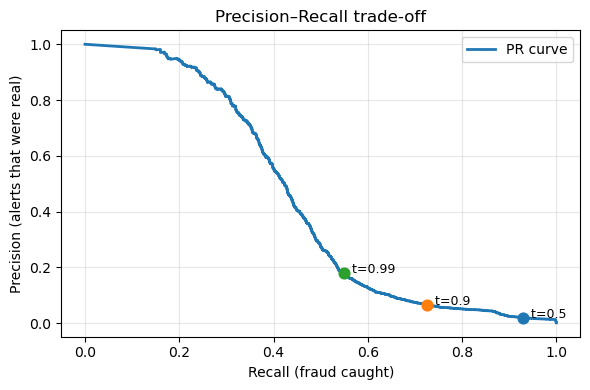

threshold=  0.5:    recall=0.930     caught 93.0% of all fraud      precision=0.020  caught=1528     missed=115     false_alarms=74724
threshold=  0.9:    recall=0.726     caught 72.6% of all fraud      precision=0.064  caught=1192     missed=451     false_alarms=17316
threshold= 0.99:    recall=0.550     caught 55.0% of all fraud      precision=0.179  caught=903     missed=740     false_alarms=4134


In [26]:
import numpy as np

prec, rec, thresh = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(rec, prec, lw=2, label="PR curve")

# Mark our three thresholds on the curve
for t in [0.5, 0.9, 0.99]:
    i = np.argmin(np.abs(thresh - t))   # point on the curve nearest threshold t
    plt.scatter(rec[i], prec[i], s=60, zorder=5)
    plt.annotate(f"  t={t}", (rec[i], prec[i]), fontsize=9)

plt.xlabel("Recall (fraud caught)")
plt.ylabel("Precision (alerts that were real)")
plt.title("Precision–Recall trade-off")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# With class_weight="balanced" the model is already eager to flag, so the useful
# lever here is RAISING the threshold to cut false alarms. Watch precision climb
# as recall eventually gives way

for t in [0.5, 0.9, 0.99]:
    pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    r = tp / (tp + fn) if (tp + fn) else 0
    p = tp / (tp + fp) if (tp + fp) else 0
    print(f"threshold={t:>5}:    recall={r:.3f}     caught {r:.1%} of all fraud      precision={p:.3f}  "
          f"caught={tp}     missed={fn}     false_alarms={fp}")



### What this is showing

We tested the fraud detector at three strictness levels and counted what happened each time.

- **Caught** — how much of the real fraud it stopped.
- **Missed** — fraud that slipped through.
- **False alarms** — honest transactions wrongly flagged as fraud.

The pattern: the stricter we make it, the fewer honest customers get bothered —
but more real fraud sneaks past. The looser we make it, we catch nearly all the
fraud, but flag a huge number of innocent transactions too.

There's no perfect setting. It's a business decision: what's worse — letting
some fraud through, or annoying good customers with false alarms?

(*"Recall" and "percent of fraud caught" are the same thing — recall is just the
technical name.*)

## 9. Unsupervised cross-check —>Isolation Forest

Isolation Forest needs **no labels**: it flags points that are easy to isolate
(unusual). This matters because it can surface *new* fraud patterns the labelled
model has never seen. We then check how much of its flagging overlaps with known
fraud —>a sanity check, not a score.

In [27]:
# Isolation Forest: finds "unusual" transactions WITHOUT being told what fraud is
# contamination=0.01 -> assume about 1% of transactions are unusual

iso = IsolationForest(contamination=0.01, random_state=RANDOM_STATE)
iso.fit(X_train)                        # learn what "normal" looks like (training data only)

# Score the test set. It returns -1 for unusual, 1 for normal -> turn -1 into a 1 flag
flags = (iso.predict(X_test) == -1).astype(int)

# Sanity check: how many flagged-as-unusual were actually known fraud?
overlap = ((flags == 1) & (y_test.values == 1)).sum()

In [28]:
print(f"Anomalies flagged in test set : {flags.sum():,} ({flags.mean():.2%})")
print(f"Of those, known fraud          : {overlap:,}")
print(f"Known fraud the anomaly view caught: {overlap / y_test.sum():.1%} of all fraud")

Anomalies flagged in test set : 12,702 (1.00%)
Of those, known fraud          : 317
Known fraud the anomaly view caught: 19.3% of all fraud


The Logistic Regression model only knows fraud because we showed it labelled examples. Isolation Forest works differently —>it gets no labels at all. It just hunts for transactions that look weird compared to the rest, on the assumption that fraud tends to be unusual.
Why bother, when we already have a fraud model? Because it can catch new, never-seen-before fraud patterns —>the kind a label-trained model would miss because it was never taught them. It's a second pair of eyes.
The last step is a sanity check: of the weird transactions it flagged, how many were actually known fraud? We're not scoring it like the main model —>just confirming its "weird" instinct points in roughly the right direction.

## 10. A validator's lens —> assumptions, limitations, next checks

This is the section that signals model-risk thinking rather than just model-building.

**Assumptions the model makes**
- Each transaction is judged on its own —> no account history, no link between
  transactions. A fraud ring using many *small* transfers would slip through
- Fraud patterns in the training period look like fraud in the future
  (rarely true forever - fraud adapts).

**Limitations**
- Logistic Regression is linear; genuinely non-linear fraud patterns need a
  richer model (then the validation bar rises too)
- The PaySim labels are simulated; real labels can be noisy and arrive late

**What I'd validate before trusting this in production**
1. **Stability/drift** —>does the input distribution move over time? (e.g. PSI)
2. **Threshold governance** —>is the cut-off owned and signed off by risk, not the modeller?
3. **Performance on a real labelled sample** —>synthetic results don't transfer.
4. **Fairness / segment checks** —>does performance hold across customer segments?
5. **Documentation & reproducibility** —>fixed seeds, versioned data, a written model rationale.

**Why this maps to the regulators**
This mirrors **SR 11-7** (conceptual soundness, outcomes analysis, ongoing
monitoring) and Canada's **OSFI Guideline E-23 —>Model Risk Management**, which
takes effect **1 May 2027** and explicitly covers AI/ML models at federally
regulated institutions.


## 11. Conclusion

A simple model already catches most of the fraud. But the real point of this
notebook isn't the model — it's *how carefully it was checked*:

- the data was split fairly, with no cheating (no leakage),
- it was judged on the right measures (catching fraud), not misleading ones (accuracy),
- the strictness setting was treated as a business decision,
- a second, label-free method was used as a cross-check, and
- the model's weaknesses and next steps were written down honestly.

In short: **build the model, then challenge it.** That second half — questioning
your own work before trusting it — is exactly of the mindset a model-r
is hired for.